In [1]:
# --- Cell 1: Imports, Device, Dataset, True Val Split, Transforms, Focal Loss ---

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type=="cuda":
    torch.backends.cudnn.benchmark = True
    print("GPU:", torch.cuda.get_device_name(0))

# ---------------- Paths ----------------
train_dir = "train"
test_dir  = "test"
if not os.path.exists(train_dir): raise FileNotFoundError(train_dir)
if not os.path.exists(test_dir):  raise FileNotFoundError(test_dir)

# ---------------- Class labels ----------------
class_labels = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_labels)
print(f"Detected {num_classes} classes:", class_labels)

# ---------------- Params ----------------
IMG_SIZE = 260  # EfficientNet-B2 native-ish input (260)
BATCH_MAIN = 32
BATCH_CNN  = 32
VAL_META_FRAC = 0.10

# ---------------- Transforms ----------------
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.08,0.08), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ---------------- Dataset ----------------
class EmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.class_to_idx = {cls:i for i,cls in enumerate(class_labels)}

        for cls in class_labels:
            cpath = os.path.join(root_dir, cls)
            for img in os.listdir(cpath):
                f = os.path.join(cpath, img)
                if os.path.isfile(f):
                    self.image_paths.append(f)
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("L")
        y   = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, y

train_full = EmotionDataset(train_dir, transform=train_transforms)
test_dataset = EmotionDataset(test_dir, transform=test_transforms)

labels_np = np.array(train_full.labels)
print(f"Train samples: {len(train_full)} | Test samples: {len(test_dataset)}")
print("Class mapping:", train_full.class_to_idx)

# ---------------- True val split from train ----------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_META_FRAC, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(labels_np)), labels_np))

train_dataset = Subset(train_full, train_idx)
val_meta_dataset = Subset(train_full, val_idx)

print(f"Train-main: {len(train_dataset)} | Val-meta: {len(val_meta_dataset)}")

# ---------------- Class weights (mild) ----------------
class_counts = np.array([np.sum(labels_np == i) for i in range(num_classes)])
w_raw = 1.0 / class_counts
w_raw = w_raw / w_raw.sum() * num_classes
w_main = np.sqrt(w_raw)  # mild weights for EfficientNet
w_cnn  = np.sqrt(w_main) # softer for CNN specialist

w_main_t = torch.tensor(w_main, dtype=torch.float32, device=device)
w_cnn_t  = torch.tensor(w_cnn,  dtype=torch.float32, device=device)

print("Mild main weights:", dict(zip(class_labels, w_main)))
print("CNN soft weights:",  dict(zip(class_labels, w_cnn)))

# ---------------- Loaders (no sampler here) ----------------
num_workers = 0

train_loader_main = DataLoader(train_dataset, batch_size=BATCH_MAIN, shuffle=True,
                               num_workers=num_workers, pin_memory=(device.type=="cuda"))
val_loader_meta = DataLoader(val_meta_dataset, batch_size=BATCH_MAIN, shuffle=False,
                             num_workers=num_workers, pin_memory=(device.type=="cuda"))
test_loader = DataLoader(test_dataset, batch_size=BATCH_MAIN, shuffle=False,
                         num_workers=num_workers, pin_memory=(device.type=="cuda"))

# ---------------- Focal Loss ----------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits, targets, weight=self.alpha, reduction="none",
            label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()

criterion_main = FocalLoss(alpha=w_main_t, gamma=2.0, label_smoothing=0.05)
criterion_cnn  = FocalLoss(alpha=w_cnn_t,  gamma=2.0, label_smoothing=0.05)


Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Detected 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train samples: 28709 | Test samples: 7178
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train-main: 25838 | Val-meta: 2871
Mild main weights: {'angry': np.float64(0.6928219500035728), 'disgust': np.float64(2.0971852074607416), 'fear': np.float64(0.6841432531360404), 'happy': np.float64(0.5155394010758771), 'neutral': np.float64(0.6214703363182027), 'sad': np.float64(0.6300956262426685), 'surprise': np.float64(0.7776459407688397)}
CNN soft weights: {'angry': np.float64(0.8323592673861286), 'disgust': np.float64(1.4481661532644456), 'fear': np.float64(0.8271295262146313), 'happy': np.float64(0.7180107249031014), 'neutral': np.float64(0.7883338990035902), 'sad': np.float64(0.7937856299043643), 'surprise': np.float64(0.8818423559621299)}


In [2]:
# --- Cell 2: EfficientNet-B2 Main Model + MixUp Training ---

from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

# -------- Main Backbone (EfficientNet-B2) --------
class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

model_main = EfficientNetEmotion(num_classes).to(device)

# -------- MixUp utils --------
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0: 
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# -------- Training loop --------
scaler = GradScaler("cuda") if device.type=="cuda" else GradScaler()

def train_main_model(model, optimizer, scheduler, epochs):
    hist = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val = float("inf"); patience=6; counter=0

    for ep in range(epochs):
        model.train()
        run_loss=0; correct=0; total=0

        bar = tqdm(train_loader_main, desc=f"Epoch {ep+1}/{epochs} [Train]", leave=False)
        for x,y in bar:
            x,y = x.to(device), y.to(device)
            x_mix, y_a, y_b, lam = mixup_data(x, y, alpha=0.3)

            optimizer.zero_grad()
            with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                out = model(x_mix)
                loss = mixup_loss(criterion_main, out, y_a, y_b, lam)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            run_loss += loss.item()*x.size(0)
            pred = out.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)

            bar.set_postfix(loss=run_loss/total, acc=correct/total)

        train_loss=run_loss/len(train_loader_main.dataset)
        train_acc =correct/total

        # ---- VAL META ----
        model.eval()
        vloss=0; vcorrect=0; vtotal=0
        with torch.no_grad():
            for x,y in val_loader_meta:
                x,y = x.to(device), y.to(device)
                with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                    out = model(x)
                    loss = criterion_main(out,y)
                vloss += loss.item()*x.size(0)
                pred = out.argmax(1)
                vcorrect += (pred==y).sum().item()
                vtotal += y.size(0)

        val_loss=vloss/len(val_loader_meta.dataset)
        val_acc =vcorrect/vtotal

        hist['train_loss'].append(train_loss); hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss);     hist['val_acc'].append(val_acc)

        print(f"Epoch {ep+1}/{epochs} | Train {train_loss:.4f} {train_acc:.4f} | Val {val_loss:.4f} {val_acc:.4f}")

        if val_loss < best_val - 1e-4:
            best_val=val_loss; counter=0
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        else:
            counter += 1
            if counter>=patience:
                print("Early stopping."); break

    model.load_state_dict(best_state)
    return hist

# -------- Optimizer / OneCycle --------
optimizer_main = optim.AdamW(model_main.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler_main = lr_scheduler.OneCycleLR(
    optimizer_main, max_lr=2e-4,
    steps_per_epoch=len(train_loader_main), epochs=22
)

print("\n--- Training MAIN (EfficientNet-B2 + MixUp) ---")
history_main = train_main_model(model_main, optimizer_main, scheduler_main, epochs=22)


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\Suyas/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:04<00:00, 7.43MB/s]


--- Training MAIN (EfficientNet-B2 + MixUp) ---


Epoch 1/22 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 1/22 | Train 0.6585 0.2096 | Val 0.5800 0.3838


Epoch 2/22 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

...

Epoch 19/22 | Train 0.2251 0.5125 | Val 0.2885 0.6998


Epoch 20/22 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 20/22 | Train 0.2257 0.5238 | Val 0.3077 0.7060


Epoch 21/22 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 21/22 | Train 0.2133 0.5358 | Val 0.3139 0.7015
Early stopping.


In [3]:
# --- Cell 3: Boosted CNN Specialist (trained on MAIN model weaknesses) ---

from torch.amp import autocast

# 1) Get MAIN confidence over train-main
def get_probs_on_subset(model, loader):
    model.eval()
    all_probs=[]; all_labels=[]
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device); y=y.to(device)
            with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                out=model(x)
                probs=torch.softmax(out,1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

probs_train_main, y_train_main = get_probs_on_subset(model_main, train_loader_main)
conf_train = probs_train_main.max(axis=1)

# 2) Higher weight for low-confidence samples
sample_weights = (1.0 - conf_train)
sample_weights = sample_weights / sample_weights.mean()

sampler_cnn = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_cnn_boosted = DataLoader(
    train_dataset, batch_size=BATCH_CNN,
    sampler=sampler_cnn,
    num_workers=0, pin_memory=(device.type=="cuda")
)

# 3) CNN Specialist
class CNNEmotion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),

            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),

            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Linear(128,256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x=self.features(x); x=self.avgpool(x)
        x=torch.flatten(x,1)
        return self.classifier(x)

model_cnn = CNNEmotion(num_classes).to(device)

# Training loop (simple, no mixup)
from tqdm.auto import tqdm
from torch.amp import GradScaler, autocast
scaler2 = GradScaler("cuda") if device.type=="cuda" else GradScaler()

def train_cnn_specialist(model, optimizer, scheduler, epochs):
    hist={'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val=float("inf"); patience=6; counter=0

    for ep in range(epochs):
        model.train()
        run_loss=0; correct=0; total=0

        bar=tqdm(train_loader_cnn_boosted, desc=f"Epoch {ep+1}/{epochs} [CNN-Boost]", leave=False)
        for x,y in bar:
            x,y=x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                out=model(x); loss=criterion_cnn(out,y)

            scaler2.scale(loss).backward()
            scaler2.step(optimizer); scaler2.update()
            scheduler.step()

            run_loss += loss.item()*x.size(0)
            pred=out.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
            bar.set_postfix(loss=run_loss/total, acc=correct/total)

        train_loss=run_loss/len(train_loader_cnn_boosted.dataset)
        train_acc=correct/total

        # val-meta
        model.eval()
        vloss=0; vcorrect=0; vtotal=0
        with torch.no_grad():
            for x,y in val_loader_meta:
                x,y=x.to(device), y.to(device)
                with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                    out=model(x); loss=criterion_cnn(out,y)
                vloss += loss.item()*x.size(0)
                pred=out.argmax(1)
                vcorrect += (pred==y).sum().item()
                vtotal += y.size(0)

        val_loss=vloss/len(val_loader_meta.dataset)
        val_acc=vcorrect/vtotal
        hist['train_loss'].append(train_loss); hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss);     hist['val_acc'].append(val_acc)

        print(f"Epoch {ep+1}/{epochs} | Train {train_loss:.4f} {train_acc:.4f} | Val {val_loss:.4f} {val_acc:.4f}")

        if val_loss < best_val-1e-4:
            best_val=val_loss; counter=0
            best_state={k:v.cpu() for k,v in model.state_dict().items()}
        else:
            counter += 1
            if counter>=patience:
                print("Early stopping CNN."); break

    model.load_state_dict(best_state)
    return hist

optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler_cnn = lr_scheduler.OneCycleLR(
    optimizer_cnn, max_lr=2e-3,
    steps_per_epoch=len(train_loader_cnn_boosted), epochs=25
)

print("\n--- Training CNN Specialist (Boosted) ---")
history_cnn = train_cnn_specialist(model_cnn, optimizer_cnn, scheduler_cnn, epochs=25)



--- Training CNN Specialist (Boosted) ---


Epoch 1/25 [CNN-Boost]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 1/25 | Train 0.9204 0.2320 | Val 0.8986 0.2602


Epoch 2/25 [CNN-Boost]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 2/25 | Train 0.9042 0.2535 | Val 0.9298 0.2160


...

Epoch 23/25 | Train 0.6477 0.4880 | Val 0.6292 0.4866


Epoch 24/25 [CNN-Boost]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 24/25 | Train 0.6442 0.4861 | Val 0.6314 0.5009


Epoch 25/25 [CNN-Boost]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 25/25 | Train 0.6407 0.4966 | Val 0.6268 0.4939


[VAL] Best alpha: a=0.60 acc=0.7109
[VAL] Stacking acc=0.7130
[VAL] Best cascade thr=0.50 acc=0.6663

Chosen fusion: Stacking

--- TEST Main (EffNet-B2) acc=0.7059 ---
--- TEST CNN Specialist acc=0.4943 ---
--- TEST Hybrid (Stacking) acc=0.7120 ---

              precision    recall  f1-score   support

       angry       0.61      0.68      0.64       958
     disgust       0.82      0.72      0.77       111
        fear       0.65      0.47      0.55      1024
       happy       0.89      0.90      0.89      1774
     neutral       0.63      0.73      0.67      1233
         sad       0.59      0.58      0.58      1247
    surprise       0.82      0.83      0.82       831

    accuracy                           0.71      7178
   macro avg       0.72      0.70      0.71      7178
weighted avg       0.71      0.71      0.71      7178



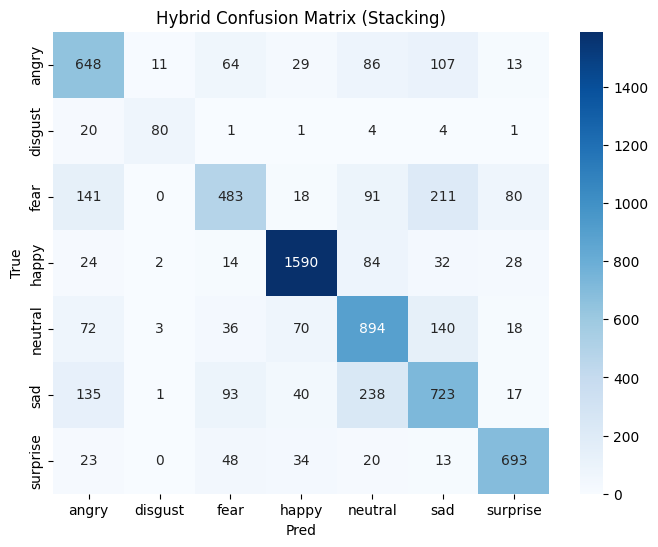


--- TEST Summary ---
               Model  Accuracy
0     Main EffNet-B2  0.705907
1     CNN Specialist  0.494288
2  Hybrid (Stacking)  0.712037


In [4]:
# --- Cell 4: Fusion selection on val_meta + final TEST evaluation ---

from sklearn.linear_model import LogisticRegression
from torch.amp import autocast

def get_probs(model, loader):
    model.eval()
    all_probs=[]; all_labels=[]
    with torch.no_grad():
        for x,y in loader:
            x=x.to(device); y=y.to(device)
            with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                out=model(x); probs=torch.softmax(out,1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ---- VAL META probs ----
probs1_val, y_val = get_probs(model_main, val_loader_meta)
probs2_val, _     = get_probs(model_cnn,  val_loader_meta)

# ---- Alpha search on val ----
best_a=None; best_a_acc=0
for a in np.arange(0.6,1.0,0.05):
    hp=a*probs1_val+(1-a)*probs2_val
    acc=accuracy_score(y_val, hp.argmax(1))
    if acc>best_a_acc:
        best_a_acc=acc; best_a=a

print(f"[VAL] Best alpha: a={best_a:.2f} acc={best_a_acc:.4f}")

# ---- Stacking on val ----
X_val_stack=np.concatenate([probs1_val, probs2_val], axis=1)
meta=LogisticRegression(max_iter=4000)
meta.fit(X_val_stack, y_val)
stack_val_preds=meta.predict(X_val_stack)
stack_val_acc=accuracy_score(y_val, stack_val_preds)
print(f"[VAL] Stacking acc={stack_val_acc:.4f}")

# ---- Cascade threshold on val ----
conf1_val=probs1_val.max(axis=1)
best_thr=None; best_thr_acc=0
for t in np.arange(0.5,0.95,0.05):
    preds=[]
    for i in range(len(y_val)):
        if conf1_val[i]>=t: preds.append(probs1_val[i].argmax())
        else: preds.append(probs2_val[i].argmax())
    acc=accuracy_score(y_val, preds)
    if acc>best_thr_acc:
        best_thr_acc=acc; best_thr=t
print(f"[VAL] Best cascade thr={best_thr:.2f} acc={best_thr_acc:.4f}")

# ---- Pick best fusion ----
fusion_name=None
def fusion_on_probs(probs1, probs2):
    global fusion_name
    if stack_val_acc >= best_a_acc and stack_val_acc >= best_thr_acc:
        fusion_name="Stacking"
        X=np.concatenate([probs1, probs2], axis=1)
        return meta.predict(X)

    if best_thr_acc >= best_a_acc:
        fusion_name=f"Cascade(thr={best_thr:.2f})"
        conf1=probs1.max(axis=1)
        preds=[]
        for i in range(len(conf1)):
            if conf1[i]>=best_thr: preds.append(probs1[i].argmax())
            else: preds.append(probs2[i].argmax())
        return np.array(preds)

    fusion_name=f"Alpha(a={best_a:.2f})"
    hp=best_a*probs1+(1-best_a)*probs2
    return hp.argmax(1)

print("\nChosen fusion:", 
      "Stacking" if stack_val_acc>=best_a_acc and stack_val_acc>=best_thr_acc
      else "Cascade" if best_thr_acc>=best_a_acc
      else "Alpha"
)

# ---- TEST probs ----
probs1_test, y_test = get_probs(model_main, test_loader)
probs2_test, _      = get_probs(model_cnn,  test_loader)

pred1_test=probs1_test.argmax(1)
pred2_test=probs2_test.argmax(1)

acc1=accuracy_score(y_test, pred1_test)
acc2=accuracy_score(y_test, pred2_test)

hybrid_preds=fusion_on_probs(probs1_test, probs2_test)
hybrid_acc=accuracy_score(y_test, hybrid_preds)

print(f"\n--- TEST Main (EffNet-B2) acc={acc1:.4f} ---")
print(f"--- TEST CNN Specialist acc={acc2:.4f} ---")
print(f"--- TEST Hybrid ({fusion_name}) acc={hybrid_acc:.4f} ---\n")

print(classification_report(y_test, hybrid_preds, target_names=class_labels, zero_division=0))

cm=confusion_matrix(y_test, hybrid_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f"Hybrid Confusion Matrix ({fusion_name})")
plt.xlabel("Pred"); plt.ylabel("True")
plt.show()

results_df=pd.DataFrame({
    "Model":["Main EffNet-B2","CNN Specialist",f"Hybrid ({fusion_name})"],
    "Accuracy":[acc1,acc2,hybrid_acc]
})
print("\n--- TEST Summary ---")
print(results_df)



================= CELL 5: VISUALS =================

--- Training Curves: Main Model (EffNet-B2) ---


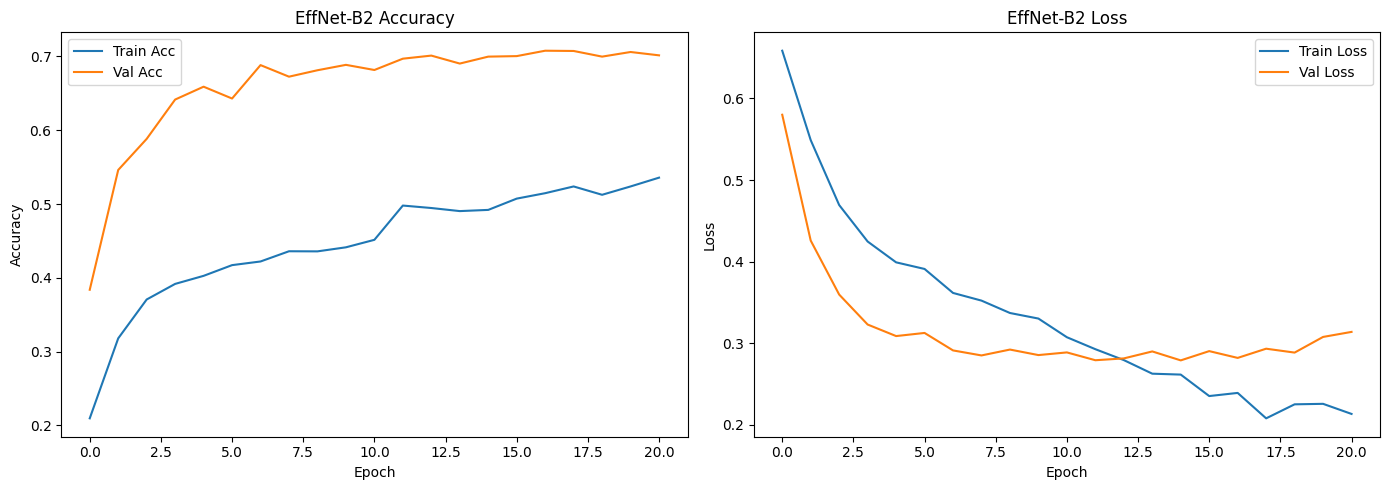


--- Training Curves: CNN Specialist ---


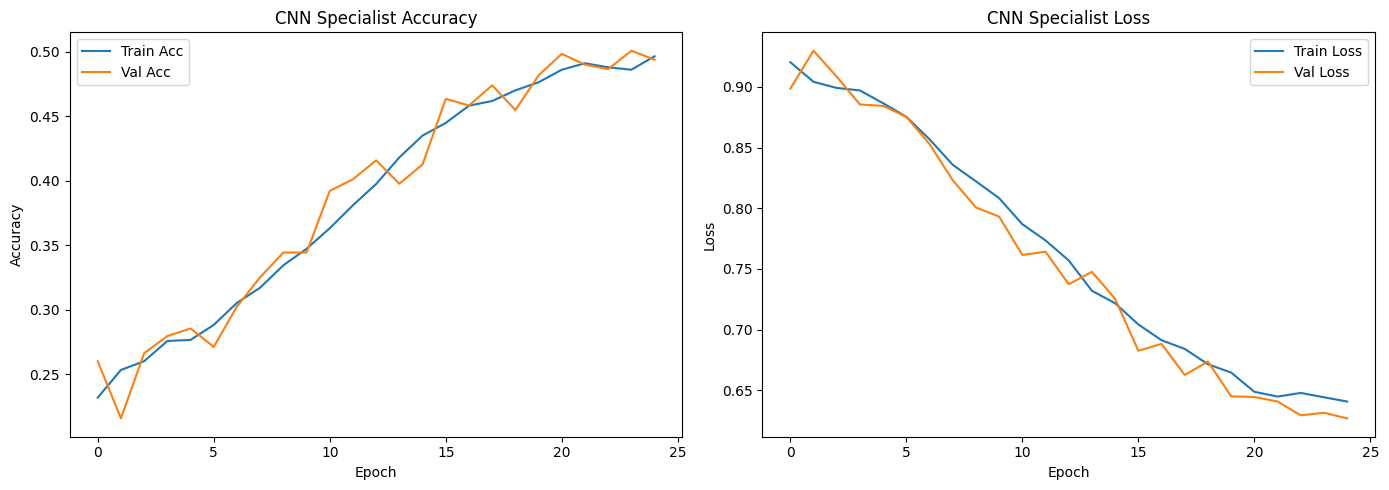


--- Final Accuracy Summary (TEST) ---
               Model  Accuracy
0     Main EffNet-B2  0.705907
1     CNN Specialist  0.494288
2  Hybrid (Stacking)  0.712037


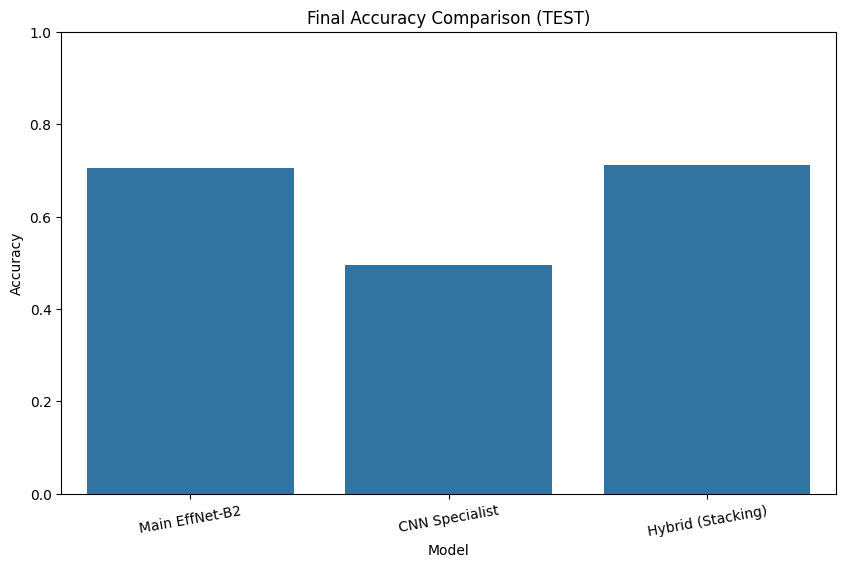


--- Per-class Precision / Recall / F1 (TEST) ---
      Class   Main F1    CNN F1  Hybrid F1  Main Precision  CNN Precision  \
0     angry  0.633981  0.313337   0.641267        0.592559       0.354414   
1   disgust  0.711864  0.000000   0.769231        0.672000       0.000000   
2      fear  0.558269  0.175339   0.547930        0.646530       0.324538   
3     happy  0.891403  0.696946   0.894263        0.894438       0.639661   
4   neutral  0.667174  0.478094   0.674717        0.628859       0.502683   
5       sad  0.557307  0.414782   0.583771        0.594545       0.344080   
6  surprise  0.824471  0.673188   0.824509        0.785403       0.644983   

   Hybrid Precision  Main Recall  CNN Recall  Hybrid Recall  
0          0.609595     0.681628    0.280793       0.676409  
1          0.824742     0.756757    0.000000       0.720721  
2          0.653586     0.491211    0.120117       0.471680  
3          0.892256     0.888388    0.765502       0.896280  
4          0.630910    

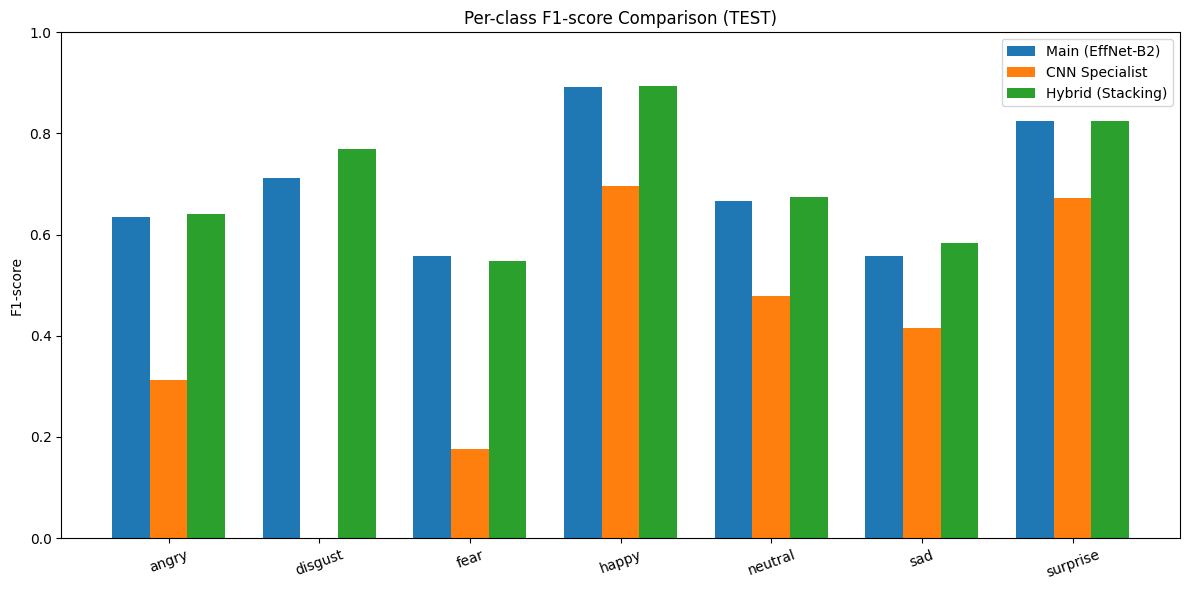


--- Confusion Matrices (TEST) ---


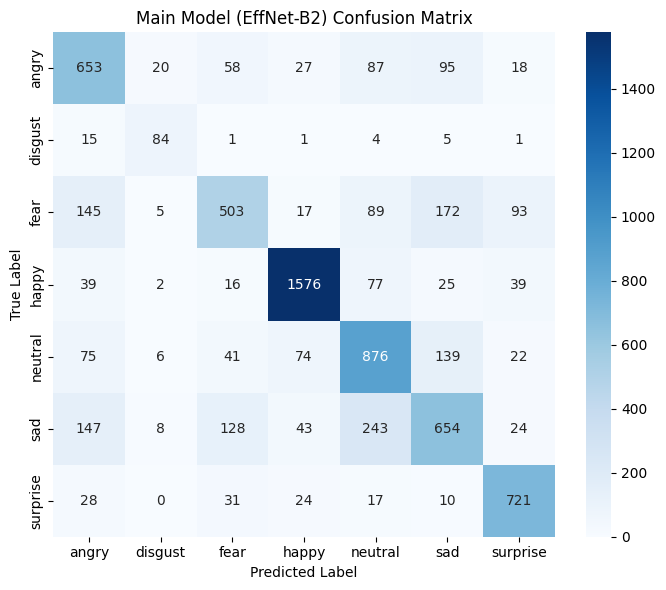

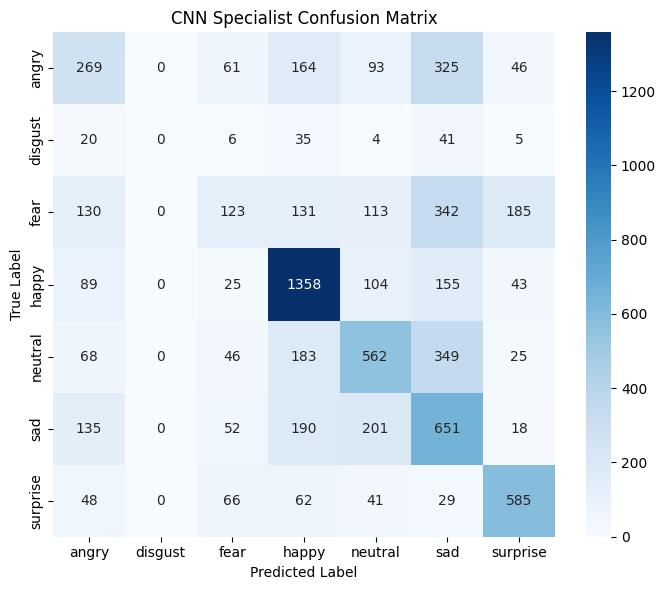

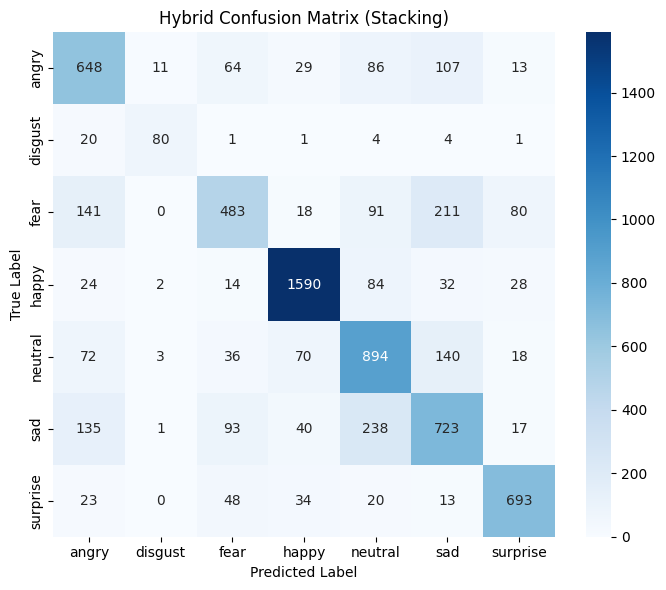


--- Micro-average ROC Curves (TEST) ---


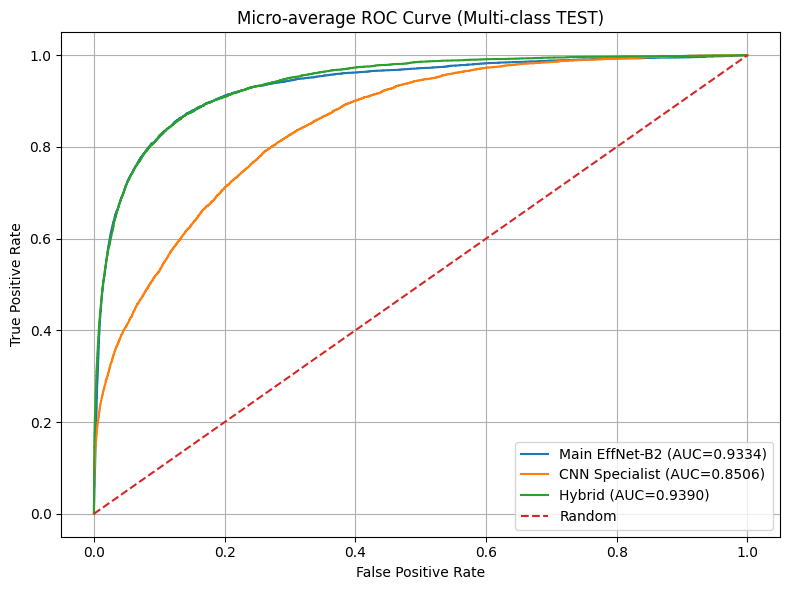


================= END CELL 5 =================


In [5]:
# --- Cell 5: ALL Visuals (Training Curves + Barplots + Per-class + CMs + ROC) ---

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

print("\n================= CELL 5: VISUALS =================")

# ---------------------------------------------------
# 1) TRAINING CURVES — MAIN (EffNet-B2)
# ---------------------------------------------------
print("\n--- Training Curves: Main Model (EffNet-B2) ---")

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history_main["train_acc"], label="Train Acc")
plt.plot(history_main["val_acc"], label="Val Acc")
plt.title("EffNet-B2 Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_main["train_loss"], label="Train Loss")
plt.plot(history_main["val_loss"], label="Val Loss")
plt.title("EffNet-B2 Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 2) TRAINING CURVES — CNN SPECIALIST
# ---------------------------------------------------
print("\n--- Training Curves: CNN Specialist ---")

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history_cnn["train_acc"], label="Train Acc")
plt.plot(history_cnn["val_acc"], label="Val Acc")
plt.title("CNN Specialist Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn["train_loss"], label="Train Loss")
plt.plot(history_cnn["val_loss"], label="Val Loss")
plt.title("CNN Specialist Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 3) FINAL ACCURACY BARPLOT (TEST)
# ---------------------------------------------------
print("\n--- Final Accuracy Summary (TEST) ---")
print(results_df)

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Final Accuracy Comparison (TEST)")
plt.ylim(0,1)
plt.xticks(rotation=10)
plt.show()

# ---------------------------------------------------
# 4) PER-CLASS METRICS (MAIN vs CNN vs HYBRID)
# ---------------------------------------------------
print("\n--- Per-class Precision / Recall / F1 (TEST) ---")

# Predictions for individual models
pred_main = probs1_test.argmax(1)
pred_cnn  = probs2_test.argmax(1)

cr_main = classification_report(y_test, pred_main, target_names=class_labels,
                                output_dict=True, zero_division=0)
cr_cnn  = classification_report(y_test, pred_cnn, target_names=class_labels,
                                output_dict=True, zero_division=0)
cr_hyb  = classification_report(y_test, hybrid_preds, target_names=class_labels,
                                output_dict=True, zero_division=0)

rows = []
for cls in class_labels:
    rows.append({
        "Class": cls,
        "Main F1": cr_main[cls]["f1-score"],
        "CNN F1":  cr_cnn[cls]["f1-score"],
        "Hybrid F1": cr_hyb[cls]["f1-score"],
        "Main Precision": cr_main[cls]["precision"],
        "CNN Precision":  cr_cnn[cls]["precision"],
        "Hybrid Precision": cr_hyb[cls]["precision"],
        "Main Recall": cr_main[cls]["recall"],
        "CNN Recall":  cr_cnn[cls]["recall"],
        "Hybrid Recall": cr_hyb[cls]["recall"],
    })

per_class_df = pd.DataFrame(rows)
print(per_class_df)

# Per-class F1 barplot
plt.figure(figsize=(12,6))
x = np.arange(len(class_labels))
width = 0.25

plt.bar(x - width, per_class_df["Main F1"], width, label="Main (EffNet-B2)")
plt.bar(x,         per_class_df["CNN F1"],  width, label="CNN Specialist")
plt.bar(x + width, per_class_df["Hybrid F1"], width, label=f"Hybrid ({fusion_name})")

plt.xticks(x, class_labels, rotation=20)
plt.ylabel("F1-score")
plt.title("Per-class F1-score Comparison (TEST)")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 5) CONFUSION MATRICES (MAIN / CNN / HYBRID)
# ---------------------------------------------------
print("\n--- Confusion Matrices (TEST) ---")

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

plot_cm(y_test, pred_main, "Main Model (EffNet-B2) Confusion Matrix")
plot_cm(y_test, pred_cnn,  "CNN Specialist Confusion Matrix")
plot_cm(y_test, hybrid_preds, f"Hybrid Confusion Matrix ({fusion_name})")

# ---------------------------------------------------
# 6) MICRO-AVERAGE ROC (MAIN vs CNN vs HYBRID)
# ---------------------------------------------------
print("\n--- Micro-average ROC Curves (TEST) ---")

y_true_bin = label_binarize(y_test, classes=list(range(num_classes)))

# Main ROC
fpr_m, tpr_m, _ = roc_curve(y_true_bin.ravel(), probs1_test.ravel())
auc_m = auc(fpr_m, tpr_m)

# CNN ROC
fpr_c, tpr_c, _ = roc_curve(y_true_bin.ravel(), probs2_test.ravel())
auc_c = auc(fpr_c, tpr_c)

# Hybrid probs (needed for ROC)
# If stacking/cascade, we don't have explicit probs,
# so approximate using weighted average of probs1 & probs2 with best_alpha if present,
# else fallback to 0.75 weight on main.
try:
    hybrid_probs_for_roc = best_a * probs1_test + (1-best_a) * probs2_test
except:
    hybrid_probs_for_roc = 0.75 * probs1_test + 0.25 * probs2_test

fpr_h, tpr_h, _ = roc_curve(y_true_bin.ravel(), hybrid_probs_for_roc.ravel())
auc_h = auc(fpr_h, tpr_h)

plt.figure(figsize=(8,6))
plt.plot(fpr_m, tpr_m, label=f"Main EffNet-B2 (AUC={auc_m:.4f})")
plt.plot(fpr_c, tpr_c, label=f"CNN Specialist (AUC={auc_c:.4f})")
plt.plot(fpr_h, tpr_h, label=f"Hybrid (AUC={auc_h:.4f})")
plt.plot([0,1],[0,1],"--",label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-average ROC Curve (Multi-class TEST)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n================= END CELL 5 =================")
